# End-to-End Retail Analytics: Predictive Churn Modeling & RFM Clustering 

In [31]:
suppressWarnings(
suppressPackageStartupMessages({
    library(tidyverse)   # cleaning and plotting
    library(mice)        # missing data imputation
    library(tidymodels)  # ML/Churn prediction
    library(infer)       # hypothesis testing
    library(tidyquant)   # monetary/financial analysis
    library(lubridate)   # InvoiceDate timestamps
    library(patchwork)   # stacking segmentation and churn plots together
    library(cluster)     # K-Means segmentation
    library(factoextra)  # visualize clusters
    library(writexl)     
    library(janitor)
    library(naniar)
    library(car)         # 1 line cross validation
    library(caret)       # VIF 
    library(pROC)}))     # ROC-AUC

## Phase 1: Data Preprocessing & Feature Engineering

In [32]:
df <- read_csv("retail_dataset.csv") %>%
    clean_names()
head(df)

Rows: 1067371 Columns: 8
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (4): Invoice, StockCode, Description, Country
dbl  (3): Quantity, Price, Customer ID
dttm (1): InvoiceDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
<chr>,<chr>,<chr>,<dbl>,<dttm>,<dbl>,<dbl>,<chr>
489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom
489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085,United Kingdom


In [33]:
summary(df)

      invoice            stock_code         description     
 Length   :1067371   Length   :1067371   Length   :1067371  
 N.unique :  53628   N.unique :   5304   N.unique :   5655  
 N.blank  :      0   N.blank  :      0   N.blank  :      0  
 Min.nchar:      6   Min.nchar:      1   Min.nchar:      1  
 Max.nchar:      7   Max.nchar:     12   Max.nchar:     35  
                                         NAs      :   4382  
                                                            
    quantity           invoice_date                     price           
 Min.   :-80995.000   Min.   :2009-12-01 07:45:00   Min.   :-53594.360  
 1st Qu.:     1.000   1st Qu.:2010-07-09 09:46:00   1st Qu.:     1.250  
 Median :     3.000   Median :2010-12-07 15:28:00   Median :     2.100  
 Mean   :     9.939   Mean   :2011-01-02 21:13:55   Mean   :     4.649  
 3rd Qu.:    10.000   3rd Qu.:2011-07-22 10:23:00   3rd Qu.:     4.150  
 Max.   : 80995.000   Max.   :2011-12-09 12:50:00   Max.   : 38970.000  
 

In [34]:
# Finding % of missing values across columns
df %>% summarise(across(everything(), ~ mean(is.na(.)) * 100))

invoice,stock_code,description,quantity,invoice_date,price,customer_id,country
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0,0.4105414,0,0,0,22.76687,0


**Note:** Roughly 23% of the values from "customer_id" are missing which is concerning. However the data doesnt state the cause of these customer_ids missing, good guessing of why the data is missing include guest checkout features, system errors or potentially even POS cash transactions. Since the goal is to run a RFM clustering and churn modelling, these missing values are excluded from the analysis. Also a very negligible amount of values are missing from the "description" column (~0.5%) maybe due to random sysetm errors. 

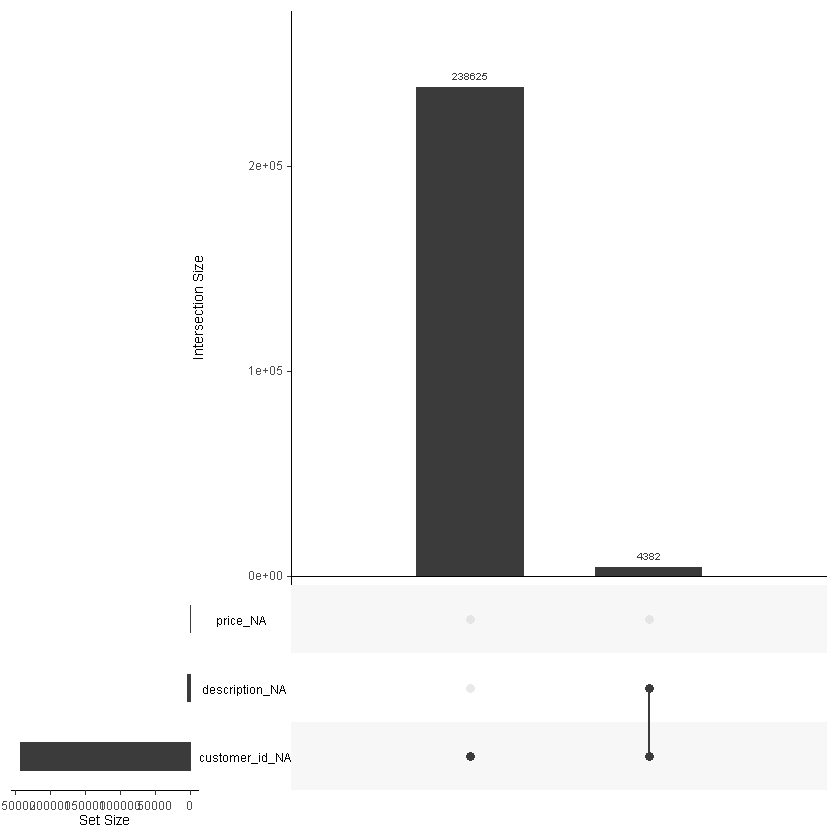

In [35]:
# Looking for any relation between the missing values of "customer_id" and "description."
suppressWarnings(gg_miss_upset(df, nsets = 3))

**Conclusion:** The plot above shows that all values missing a descrpition are also missing a customer_id (100% correlation between missing description and missing customer_id). This confirms that the descrpition missing values are not random and are due to a system fault.

In [36]:
# Removing the NA values from the dataset 
df_cleaned <- df %>%
    filter(!is.na(customer_id))

In [37]:
# Counting the number of orders per customer
all_orders <- df_cleaned %>%
    group_by(customer_id) %>%
    summarize(total_orders = n_distinct(invoice))     # total orders include cancelled orders
head(all_orders)

customer_id,total_orders
<dbl>,<int>
12346,17
12347,8
12348,5
12349,5
12350,1
12351,1


In [38]:
# Counting the number of cancelled orders per customer
cancellations <- df_cleaned %>%
    filter(str_detect(invoice, "(?i)^c")) %>%
    group_by(customer_id) %>%
    summarize(canceled_orders = n_distinct(invoice))
head(cancellations)

customer_id,canceled_orders
<dbl>,<int>
12346,5
12349,1
12352,3
12359,4
12360,1
12362,3


In [39]:
customer_cancellations <- all_orders %>%
    left_join(cancellations, by = "customer_id") %>%
    mutate(canceled_orders = replace_na(canceled_orders, 0),
    cancellation_rate = canceled_orders / total_orders)
head(customer_cancellations)

customer_id,total_orders,canceled_orders,cancellation_rate
<dbl>,<int>,<int>,<dbl>
12346,17,5,0.2941176
12347,8,0,0.0000000
12348,5,0,0.0000000
12349,5,1,0.2000000
12350,1,0,0.0000000
12351,1,0,0.0000000


## Phase 2: RFM (Recency, Frequency, Monetary) Engineering

In [40]:
# Looking at customer recency as if the analysis is done one day after the data collection stopped in 2011, giving the date 10/12/2011 - affects the churn model otherwise
todays_date <- as_date(max(df_cleaned$invoice_date, na.rm = TRUE)) + days(1)
todays_date

# Finding all irregular stock codes
irregular_codes <- df_cleaned %>%
    filter(!str_detect(stock_code, "^[0-9]")) %>%
    group_by(stock_code, description) %>%
    summarize(occurences = n(), .groups = "drop") %>%
    arrange(desc(occurences))
irregular_codes

[1] "2011-12-10"

stock_code,description,occurences
<chr>,<chr>,<int>
POST,POSTAGE,2019
M,Manual,1115
C2,CARRIAGE,259
D,Discount,174
BANK CHARGES,Bank Charges,38
ADJUST,Adjustment by john on 26/01/2010 16,36
ADJUST,Adjustment by john on 26/01/2010 17,22
PADS,PADS TO MATCH ALL CUSHIONS,19
CRUK,CRUK Commission,16


In [41]:
# Main RFM cell - drop useless values and make the RFM dataset
excluded_codes <- c("POST", "D", "M", "BANK FEES", "BANK CHARGES", "C2", "DOT", "CRUK", "PADS", "TEST001", "TEST002")
rfm <- df_cleaned %>%
    filter(!str_detect(invoice, "(?i)^c")) %>%
    filter(!stock_code %in% excluded_codes) %>%
    filter(!str_detect(description, "(?i)Adjustment")) %>%
    group_by(customer_id) %>%
    summarize(recency = as.numeric(difftime(todays_date, as_date(max(invoice_date)), units = "days")), # last purchase
              frequency = n_distinct(invoice), # how many times they returned
              monetary = sum(quantity * price), # total amount spent
              total_items = sum(quantity), 
              avg_items = total_items / frequency, 
              avg_unit_price = mean(price), 
              log_monetary = log(monetary + 1)) %>%
    ungroup()
head(rfm)

customer_id,recency,frequency,monetary,total_items,avg_items,avg_unit_price,log_monetary
<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12346,326,3,77352.96,74239,24746.3333,6.8160000,11.256147
12347,3,8,5633.32,3286,410.7500,2.5460870,8.636632
12348,76,5,1658.40,2704,540.8000,0.6978261,7.414211
12349,19,3,3678.69,1621,540.3333,4.2467442,8.210584
12350,311,1,294.40,196,196.0000,1.5812500,5.688330
12351,376,1,300.93,261,261.0000,2.3552381,5.710195


In [42]:
# merging cancellation table with RFM table
main_set <- customer_cancellations %>%
    left_join(rfm, by="customer_id") %>% 
    mutate(recency = replace_na(recency, as.numeric(difftime(todays_date, as_date(min(df_cleaned$invoice_date)), units = "days"))),
    frequency = replace_na(frequency, 0),
    monetary = replace_na(monetary, 0),
    log_monetary = replace_na(log_monetary, 0),
    total_items = replace_na(total_items, 0),
    avg_items = replace_na(avg_items, 0),
    avg_unit_price = replace_na(avg_unit_price, 0))
head(main_set)

customer_id,total_orders,canceled_orders,cancellation_rate,recency,frequency,monetary,total_items,avg_items,avg_unit_price,log_monetary
<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12346,17,5,0.2941176,326,3,77352.96,74239,24746.3333,6.8160000,11.256147
12347,8,0,0.0000000,3,8,5633.32,3286,410.7500,2.5460870,8.636632
12348,5,0,0.0000000,76,5,1658.40,2704,540.8000,0.6978261,7.414211
12349,5,1,0.2000000,19,3,3678.69,1621,540.3333,4.2467442,8.210584
12350,1,0,0.0000000,311,1,294.40,196,196.0000,1.5812500,5.688330
12351,1,0,0.0000000,376,1,300.93,261,261.0000,2.3552381,5.710195


## Phase 3: Customer Segmentation by K-means Clustering

In [43]:
# choosing main variables for the clustering and z-score scaling
cluster_set <- main_set %>%
    select(recency, frequency, log_monetary, avg_items, avg_unit_price, cancellation_rate)
scaled_set <- scale(cluster_set)
head(scaled_set)

recency,frequency,log_monetary,avg_items,avg_unit_price,cancellation_rate
0.5401696,-0.2491907,2.8213564,16.73780159,0.4886773,0.8956192
-0.9480580,0.1452185,1.1904360,0.10538690,-0.1132314,-0.6762015
-0.6117094,-0.0914270,0.4293524,0.19427096,-0.3737716,-0.6762015
-0.8743378,-0.2491907,0.9251769,0.19395201,0.1265019,0.3926365
0.4710569,-0.4069544,-0.6451878,-0.04138629,-0.2492397,-0.6762015
0.7705454,-0.4069544,-0.6315747,0.00303866,-0.1401344,-0.6762015


In [ ]:
# Calculating WCSS and Silhouette for different amounts of clusters (chose 8 as the upper limit for clusters as it is more reasonable for retail businesses)
optimization_metrics <- map_df(2:8, function(k) {
    k_means <- kmeans(scaled_set, centers = k, nstart = 25) 
    sil_matrix <- silhouette(k_means$cluster, dist(scaled_set))
    tibble(k = k, wcss = k_means$tot.withinss, silhouette = mean(sil_matrix[, 3]))})
suppressWarnings(optimization_metrics)

In [ ]:
# Plotting an elbow and silhouette plot to visually identify the best k value
p1 <- ggplot(optimization_metrics, aes(x = k, y = wcss)) + 
    geom_line(linewidth = 1) + 
    geom_point(size = 3) + 
    scale_x_continuous(breaks = 2:8) + 
    theme_minimal() + 
    labs(x = "Number of Clusters (k)", y = "Total within-cluster sum of squares", title = "Elbow Plot")
p2 <- ggplot(optimization_metrics, aes(x = k, y = silhouette)) +
    geom_line(linewidth = 1) +
    geom_point(size = 3) +
    scale_x_continuous(breaks = 2:8) +
    theme_minimal() +
    labs(x = "Number of Clusters (K)", y = "Silhouette Score", title = "Silhouette Plot", )
p1 / p2

**Conclusion:** Based on the above optimization plots, K = 4 has the seems ideal since it balances accuracy and business value. The silhouette score climbs steadily till K = 4 before dropping steeply at K = 5 indicating that 5 clusters would lead to messy overlapping groups. The elbow plot on the other hand shows almost even drops throughout the clusters which doesn't really help in selecting a specific k value unless paired with another cluster selection model in this the case silhouette metrics. Though the silhouette score climbs back up after K = 5 and has a better score after K = 7, having more 7+ clusters could be because of overfitting and provides lesser operational value for businesses as 7+ strategies may be too excessive and inefficient. 

In [ ]:
# Training the Model (K = 4)
set.seed(42)
k <- 4
final_kmeans <- kmeans(scaled_set, centers = k, nstart = 50)
main_set <- main_set %>%
    mutate(cluster = as.factor(final_kmeans$cluster))
table(main_set$cluster)

In [ ]:
# Investigating group 1 with 3 members - suspecting them being wholesale buyers
main_set %>% filter(cluster == 1)

The table above confirms that cluster 1 consists of wholesale buyers. This is seen as the buyers have a low frequency, visiting the store only 1-5 times but having purchased a huge volume of items during each visit. Their massive basket sizes set them apart and therefore the model put them all in one cluster.

In [ ]:
# Principal Component Analysis for the final visualization
pca_transform <- prcomp(scaled_set, center = FALSE, scale. = FALSE)
pca_data <- tibble(PC1 = pca_transform$x[, 1],   
                   PC2 = pca_transform$x[, 2],
                   cluster = main_set$cluster)
final_plot <- ggplot(pca_data, aes(x = PC1, PC2, color = cluster)) + 
    geom_point(alpha = 0.5, size = 1.8) + 
    theme_minimal() + 
    labs(x = "Principal Component 1", y = "Principal Component 2", color = "Customer Cluster", title = "Multi-dimensional Customer Cluster")
final_plot

Cluster 1 makes the plot hard to read. Plotting clusters 2-4 below for a better understanding. 

In [ ]:
zoomed_data <- pca_data %>% filter(cluster != 1)
zoomed_plot <- ggplot(zoomed_data, aes(x = PC1, PC2, color = cluster)) + 
    geom_point(alpha = 0.5, size = 1.8) + 
    theme_minimal() + 
    labs(x = "Principal Component 1", y = "Principal Component 2", color = "Customer Cluster", title = "Multi-dimensional Customer Cluster")
zoomed_plot

In [ ]:
pca_transform

**Interpretation of entire Principal Component Analysis:** 
- Principal Component 1 (PC1): This helps us plot the customer engagement and their lifetime value. " Frequency and log_monetary move in the positive direction while recency moves in the negative direction. Note that a negative recency is good, as that shows that the customer recently shopped at the store. 
- Principal Component 2 (PC2): This helps us plot a customer's order behaviour and cancellation risks. Cancellation_rate and avg_items are in the positive direction, and avg_unit_price is in the negative direction. Ingores spends but looks at customer behaviour at checkout. 
- Plot 1: The first plot shows all 4 clusters, highlighting the cluster with extreme outliers (cluster 1), which represents huge clients that purchase huge volumes and spend a lot more than the regular customer; this pulls them high up on the PC2 axis. This cluster makes it hard to read the remaining clusters clearly since they are so high up on the PC2 axis, which was excluded in the second plot.
- Plot 2: The second plot is more zoomed in, as cluster 1 is ignored, it is visible that cluster 2 (red) extends along principal component 1, capturing wholesale customers that spend more and have larger average basket sizes, indicating wholesale customers that have high spending and visit frequently. Meanwhile, cluster 3 (green) and cluster 4 (blue) represent the retail customer base; they are tightly packed around the origin but spread across principal component 2, separating active frequent customers from low-frequency at-risk customers.

**Final Business Takeaways from Phase 3 (Customer Segmentation):**

While our customer base is dominated by retail shoppers by a ratio of approximately 2-to-1, the wholesale buyers in Cluster 2 represent a huge concentration of high-frequency revenue. The churn risk across these groups is highly asymmetric; retail customers (Clusters 3 and 4) show a high probability of churning but represent a low-impact risk, while wholesale buyers represent a low-probability but high-impact risk to the business. Integrating these 4 different groups onto our database provides our predictive churn model with the critical context it needs for Phase 4.

## Phase 4: Predictive Churn Modeling

In [ ]:
# 1. look at distribution of recency column and find the churn cutoff (eg 90days) and then flag and churned or no (1/0) and create the churned target var
# 2. Run a VIF for multicollinearity 
# 3. Split dataset 80-20
# 4. Train model (logistic regression)
# 5. Extract statistical inference (% change churn risk for each behaviour and calculate CI) and odds ratios
# 6. evaluation matrix (confusion matrix, ROC-AUC, Recall/Sensitivity)

In [ ]:
# Setting churn cutoff as 90 days, as it accounts for customer seasonality and wholesale restocks while also leaving time for customer retention attempts.
main_set <- main_set %>%
    mutate(churn = if_else(recency > 90, 1, 0))

In [ ]:
# Split dataset (80 training/20 testing)
set.seed(123)
data_split <- initial_split(main_set, prop = 0.8, strata = churn)
train_data <- training(data_split)
testing_data <- testing(data_split)

In [ ]:
# 5-fold stratified cross-validation to ensure metrics are stable against variance due to data splitting
cv_control <- trainControl(method = "cv", number = 5)

cv_model <- suppressWarnings(
    train(as.factor(churn) ~ frequency + log_monetary + avg_items + avg_unit_price + cancellation_rate + cluster, 
          data = train_data, 
          method = "glm",
          family = "binomial",
          trControl = cv_control))
print(cv_model$results)

In [ ]:
# Defining the model - leaving out recency from the model, as churn depends on recency, adding recency makes the prediction useless
final_churn_model <- glm(churn ~ frequency + log_monetary + avg_items + avg_unit_price + cancellation_rate + cluster,
                         data = train_data,
                         family = binomial(link = "logit"))
summary(final_churn_model)

In [ ]:
# Checking for multicollinearity
vif(final_churn_model)

None of the variables have a VIF greater than 5, proving their independence. Cluster does have a VIF for 18.65 but is because it is a categorical variable and has 3 degrees of freedom, when accounting for that the adjusted score is 1.63 which is perfect

In [ ]:
# Exponentiating the coefficients and CIs
odds_ratios <- suppressWarnings(exp(coef(final_churn_model)))
conf_intervals <- suppressWarnings(exp(confint(final_churn_model)))

inference_table <- cbind(Odds_Ratio = odds_ratios, conf_intervals)
inference_table

**Interpretation for every variable:**

<u>Drivers of Churn</u>
- Cancellation Rate (OR = 2.68): Customers with spiking cancellation habits are ~2.7 times more likely to churn. We are 95% confident in our estimation procedure that the true churn risk multiplier sits between 1.16x and 6.23x.
- Average Unit Price (OR = 1.10): Customers who buy more expensive individual items carry a higher churn risk. Every 1-pound increase in average item price increases the odds of churn by ~10%. (95% CI: 1.05 to 1.16).
- Cluster 4: The model flagged our algorithmic "Cluster 4" demographic as an extreme churn risk, meaning customers who make up this group are highly unstable and may churn. We are 95% confident the true risk multiplier sits between 144.1x and 49,491,740x. This wide range indicates a quasi-complete separation, meaning that almost every single customer in that cluster abandoned the platform.

<u>Drivers of Loyalty</u>
- Purchase Frequency (OR = 0.92): Because the Odds Ratio is under 1.0, it acts as a protective factor to avoid churn. Every additional order a customer places reduces their churn risk by ~7%. We are 95% confident the true multiplier sits between 0.906x and 0.950x.

<u>Noise (Statistically Insignificant)</u>
- Total Spend (log_monetary): The 95% confidence interval spans from 0.94 to 1.16. Since this range crosses 1.0, we cannot confidently say that lifetime spend has any impact on churn once we account for their frequency and cancellation habits.
- Basket Size (avg_items): The interval sits at exactly 1.000002 to 1.000257. While statistically significant, the multiplier is really close to 1.0. An increase in basket size has zero actionable impact on a customer's likelihood to leave.
- Clusters 2 & 3: The 95% confidence intervals are 0.12 to 34,623 and 0.25 to 72,867 for clusters 2 and 3, respectively, both cross 1.0. This proves the model cannot reliably distinguish their churn risk from the baseline cluster.

In [ ]:
# Predict probabilities and confusion matrix (0.50 threshold)
testing_data$churn_prob <- predict(final_churn_model, newdata = testing_data, type = "response")
testing_data$final_pred <- if_else(testing_data$churn_prob > 0.50, 1, 0)

evaluation_matrix <- table(Predicted = testing_data$final_pred, Actual = testing_data$churn)
evaluation_matrix

In [ ]:
# Recall / Sensitivity
true_positives <- evaluation_matrix["1", "1"]
false_negatives <- evaluation_matrix["0", "1"]
recall_score <- true_positives / (true_positives + false_negatives)
print(paste("Recall (Sensitivity):", round(recall_score, 4)))

In [ ]:
# ROC-AUC Score
roc_obj <- roc(testing_data$churn, testing_data$churn_prob)
print(paste("ROC-AUC Score:", round(auc(roc_obj), 4)))

**Model Evaluation:**

1. Model Intelligence (ROC-AUC)
An ROC-AUC score of 86% proves that our model's logic is highly accurate. It has successfully learned the behavioral patterns of our dataset and is capable of separating loyal customers from actual churn risks.

2. Model Execution (Recall: 58.82%)
50% probability threshold is strict, but our model successfully caught ~6 out of every 10 actual churners. It missed the other 4 because it is currently very conservative, avoiding false positives, which is why it only triggered 3 false alarms out of 578 active customers.

3. Real-World Business Strategy
In reality, missing a high-value churner is much more expensive than sending a discount code to a loyal customer. We do not need to retrain the model to fix this conservative bias. To cast a wider range, we could set the churn_probability to a lower threshold to push our Recall into the 80%+ range.

In [ ]:
# Making the final dataset for Tableau
main_set$churn_probability <- predict(final_churn_model, newdata = main_set, type = "response")
final_tableau_export <- main_set %>%
  select(customer_id, recency, frequency, monetary, cancellation_rate, cluster, churn_probability)
write_xlsx(final_tableau_export, "master_customer_data.xlsx")